In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [19]:
# ЗАВДАННЯ 1.1: Вибір та завантаження набору даних
df = pd.read_csv('london_weather.csv')

# ЗАВДАННЯ 1.2: Базова підготовка даних
# Зміна типів даних: Конвертуємо цілі числа (19790101) у справжній формат дати
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')

# Обробка пропусків: Заповнюємо пропущені значення медіаною
df = df.fillna(df.median(numeric_only=True))

# СТВОРЕННЯ КАТЕГОРІАЛЬНИХ ОЗНАК (в датасеті лише числа)
# 1. Текстова колонка "Сезон"
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

df['season'] = df['date'].dt.month.apply(get_season)

# 2. Текстова колонка "Тип погоди"
def get_weather_type(row):
    if row['precipitation'] > 0: return 'Rainy'
    elif row['cloud_cover'] >= 6: return 'Cloudy'
    else: return 'Sunny'

df['weather_type'] = df.apply(get_weather_type, axis=1)

# Виведення перших рядків для перевірки (теж вимога пункту 1.1/1.2)
print(df[['date', 'season', 'weather_type']].head())

        date  season weather_type
0 1979-01-01  Winter        Rainy
1 1979-01-02  Winter       Cloudy
2 1979-01-03  Winter        Sunny
3 1979-01-04  Winter       Cloudy
4 1979-01-05  Winter       Cloudy


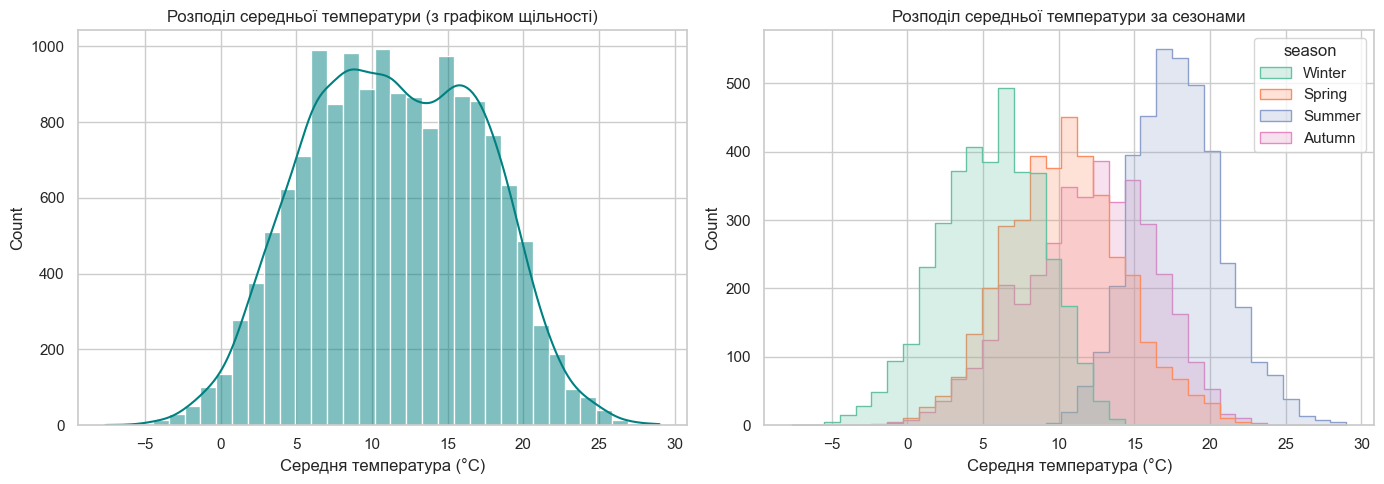

In [20]:
# ЗАВДАННЯ 2.1: Розподіл однієї змінної

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Гістограма та графік щільності (KDE) для змінної mean_temp
# Змінюємо колір на 'teal' і налаштовуємо кількість інтервалів (bins=35)
sns.histplot(df['mean_temp'], bins=35, kde=True, color='teal', ax=axes[0])
axes[0].set_title('Розподіл середньої температури (з графіком щільності)')
axes[0].set_xlabel('Середня температура (°C)')

# 2. Гістограми для груп за категоріальною змінною 'season'
sns.histplot(data=df, x='mean_temp', hue='season', bins=35, element='step', palette='Set2', ax=axes[1])
axes[1].set_title('Розподіл середньої температури за сезонами')
axes[1].set_xlabel('Середня температура (°C)')

plt.tight_layout()
plt.show()

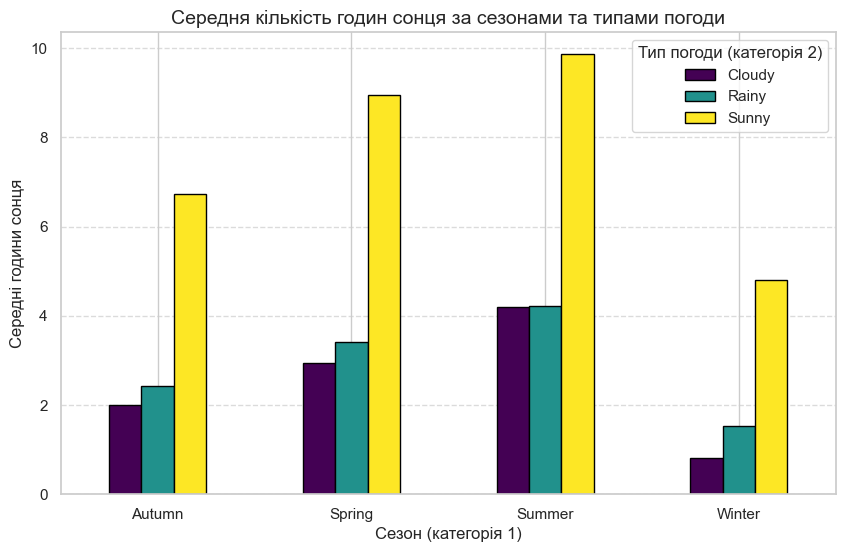

In [21]:
# ЗАВДАННЯ 2.2: Порівняння категорій (Стовпчикова діаграма)

# Рахуємо середню кількість годин сонця (sunshine) для різних сезонів (season), і додаємо третій вимір - тип погоди (weather_type)
sunshine_grouped = df.groupby(['season', 'weather_type'])['sunshine'].mean().unstack()

# Будуємо графік використовуючи pandas.DataFrame.plot.bar
sunshine_grouped.plot(kind='bar', figsize=(10, 6), colormap='viridis', edgecolor='black')

plt.title('Середня кількість годин сонця за сезонами та типами погоди', fontsize=14)
plt.xlabel('Сезон (категорія 1)')
plt.ylabel('Середні години сонця')
plt.xticks(rotation=0)
plt.legend(title='Тип погоди (категорія 2)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

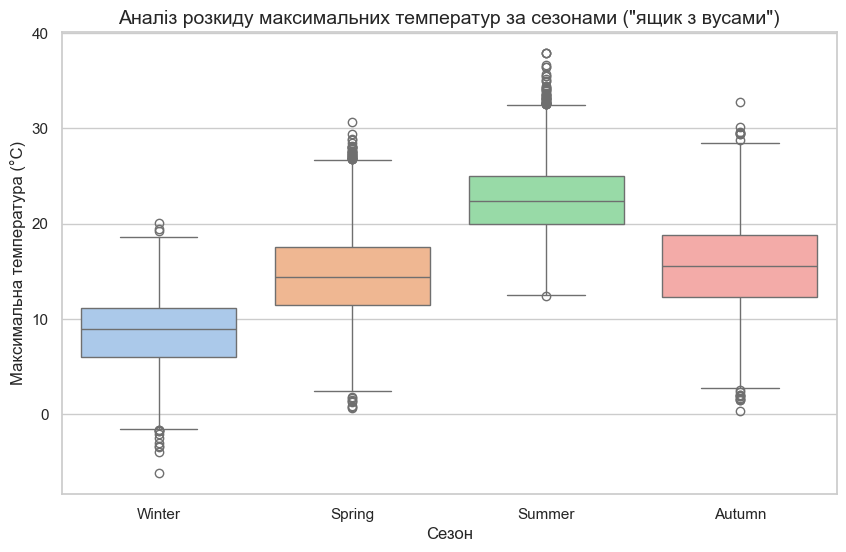

In [22]:
# ЗАВДАННЯ 2.3: Аналіз розкиду та викидів (Box plot)

plt.figure(figsize=(10, 6))

# Вісь X – категорійна змінна (season)
# Вісь Y – числова змінна (max_temp)
sns.boxplot(data=df, x='season', y='max_temp', palette='pastel', hue='season', legend=False)

plt.title('Аналіз розкиду максимальних температур за сезонами ("ящик з вусами")', fontsize=14)
plt.xlabel('Сезон')
plt.ylabel('Максимальна температура (°C)')
plt.show()

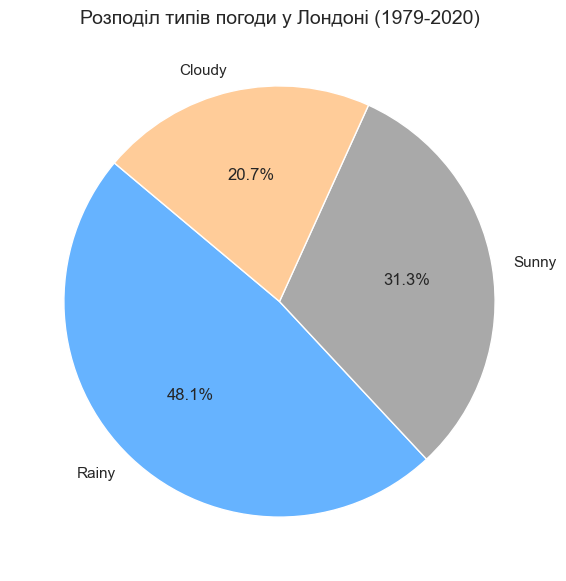

In [23]:
# ЗАВДАННЯ 2.4: Розподіл категорійної змінної (Pie plot)

plt.figure(figsize=(7, 7))
weather_counts = df['weather_type'].value_counts()

# Кругова діаграма
plt.pie(weather_counts, labels=weather_counts.index, autopct='%1.1f%%',
        colors=['#66b3ff', '#A9A9A9', '#ffcc99'], startangle=140)

plt.title('Розподіл типів погоди у Лондоні (1979-2020)', fontsize=14)
plt.show()

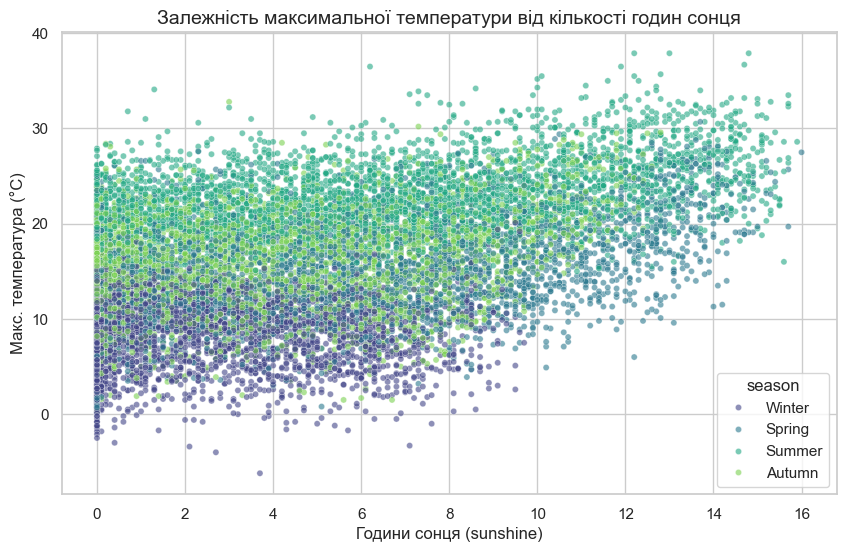

In [24]:
# ЗАВДАННЯ 2.5: Взаємозвʼязок двох числових змінних (Scatter plot)

plt.figure(figsize=(10, 6))

# Точкова діаграма з розфарбуванням по третій (категорійній) змінній - season
sns.scatterplot(data=df, x='sunshine', y='max_temp', hue='season',
                palette='viridis', alpha=0.6, s=20)

plt.title('Залежність максимальної температури від кількості годин сонця', fontsize=14)
plt.xlabel('Години сонця (sunshine)')
plt.ylabel('Макс. температура (°C)')
plt.show()

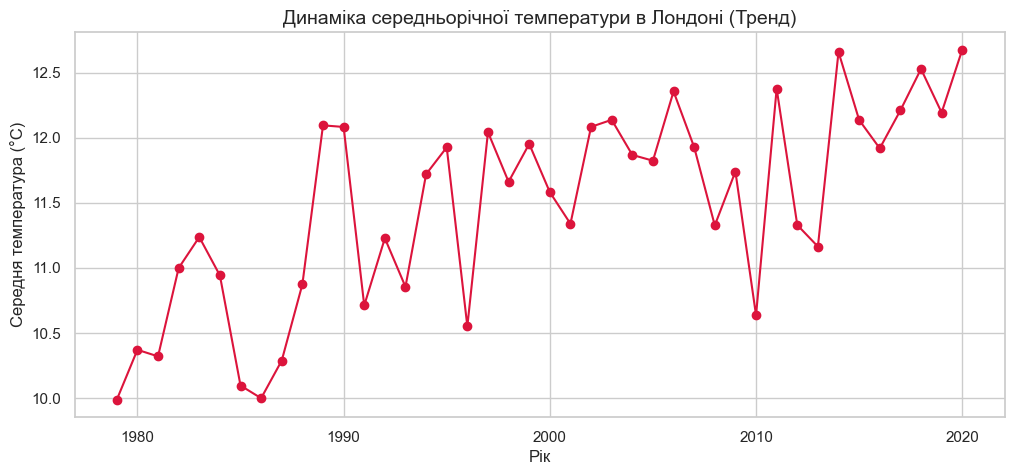

In [25]:
# ЗАВДАННЯ 2.6: Динаміка або тренд (Line plot)

plt.figure(figsize=(12, 5))

# Групуємо дані по роках (хронологічний порядок) та рахуємо середню температуру
df['year'] = df['date'].dt.year
yearly_temp = df.groupby('year')['mean_temp'].mean()

# Лінійний графік
plt.plot(yearly_temp.index, yearly_temp.values, marker='o', linestyle='-', color='crimson')

plt.title('Динаміка середньорічної температури в Лондоні (Тренд)', fontsize=14)
plt.xlabel('Рік')
plt.ylabel('Середня температура (°C)')
plt.grid(True)
plt.show()

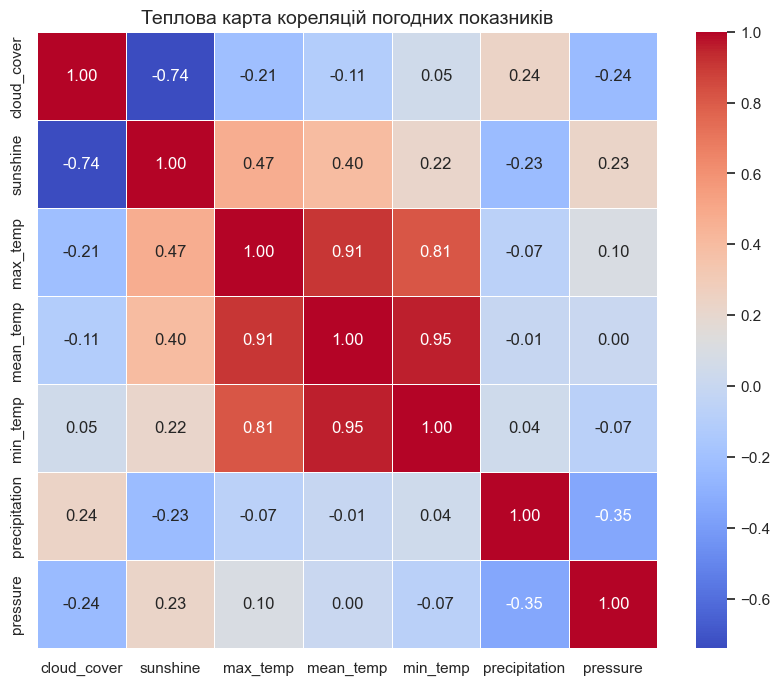

In [26]:
# ЗАВДАННЯ 2.7: Матриця кореляцій (Heatmap)

plt.figure(figsize=(10, 8))

# Вибираємо тільки числові колонки для матриці
numeric_cols = ['cloud_cover', 'sunshine', 'max_temp', 'mean_temp', 'min_temp', 'precipitation', 'pressure']
corr_matrix = df[numeric_cols].corr()

# Теплова карта з відображенням числових значень (annot=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Теплова карта кореляцій погодних показників', fontsize=14)
plt.show()

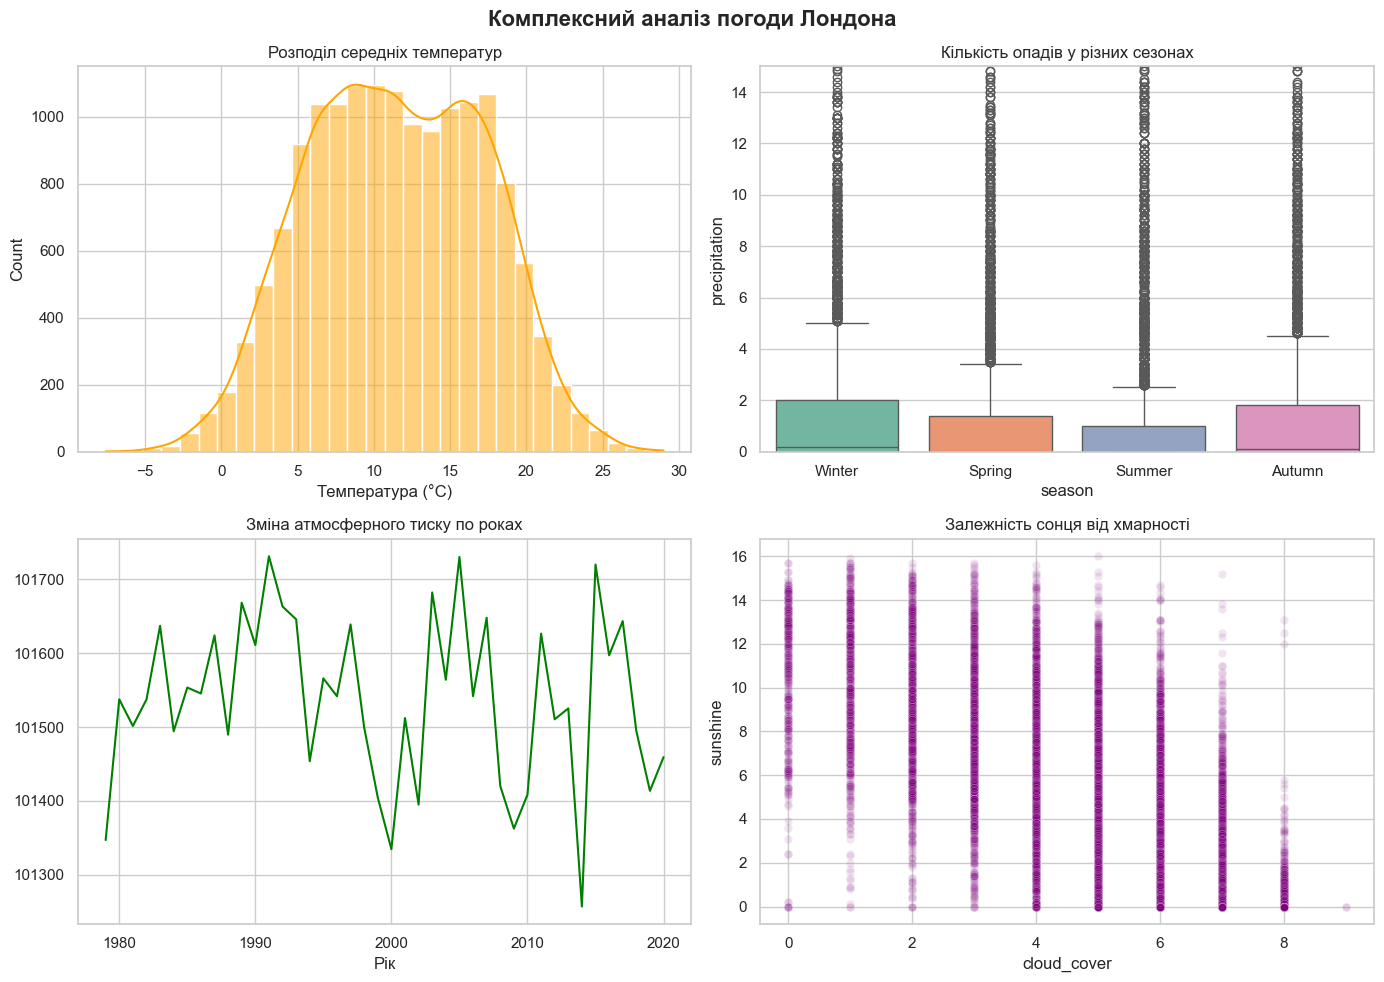

In [27]:
# ЗАВДАННЯ 2.8: Комбінований графік (plt.subplots)

# Створюємо сітку 2x2 (дашборд)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Комплексний аналіз погоди Лондона', fontsize=16, fontweight='bold')

# 1. Гістограма температур (верхній лівий)
sns.histplot(df['mean_temp'], bins=30, kde=True, ax=axes[0, 0], color='orange')
axes[0, 0].set_title('Розподіл середніх температур')
axes[0, 0].set_xlabel('Температура (°C)')

# 2. Опади по сезонах (верхній правий) - Boxplot
sns.boxplot(data=df, x='season', y='precipitation', ax=axes[0, 1], palette='Set2', hue='season', legend=False)
axes[0, 1].set_title('Кількість опадів у різних сезонах')
axes[0, 1].set_ylim(0, 15) # Обмежимо вісь Y, щоб прибрати сильні викиди візуально

# 3. Лінійний тренд тиску (нижній лівий)
yearly_pressure = df.groupby('year')['pressure'].mean()
axes[1, 0].plot(yearly_pressure.index, yearly_pressure.values, color='green')
axes[1, 0].set_title('Зміна атмосферного тиску по роках')
axes[1, 0].set_xlabel('Рік')

# 4. Сонце vs Хмарність (нижній правий)
sns.scatterplot(data=df, x='cloud_cover', y='sunshine', ax=axes[1, 1], color='purple', alpha=0.1)
axes[1, 1].set_title('Залежність сонця від хмарності')

plt.tight_layout()
plt.show()